# FLMVDM Noise Schedule Explorer

Use this notebook to sample `tau` values and inspect how each FLMVDM schedule maps them to `gamma`, `SNR`, `alpha`, and VLB/SNR-prime weights. The time convention is the FLM convention: `tau=0` is noise and `tau=1` is data.

In [11]:
# Main controls
SCHEDULE_TYPE = "linear_alpha"  # linear, learned_vdm, argmax_uncertainty, snr_power, linear_alpha, cosine_alpha, ode_alpha , piecewise_alpha
LATENT_TYPE = "linear_interp"           # vp or linear_interp
IMPORTANCE_SAMPLING = True

N_SAMPLES = 10_000
GRID_POINTS = 1_000
SEED = 0

# Use a clipped interval for schedules with singular endpoints, especially snr_power.
T_MIN = 0.
T_MAX = 1.0

SCHEDULE_PARAMS = {
    "gamma_min": -4,
    "gamma_max": 20,
    "C": 16,#17.276323318481445,
    "p": 0.2,#0.43169814348220825,
    "eps": 1e-6,
    "hidden_size": 128,
    "vocab_size": 30_522, #50_257,
    # Lower this for fast interactive argmax_uncertainty exploration.
    "n_points": 2_000,
    "n_gh": 64,
    "interpolation": "pchip",  # pchip, cubic
    "alpha_min": 0.0,
    "alpha_max": 0.9,
    "val_alpha_min": None,
    "val_alpha_max": None,
    "bisect_iters": 256,
    # Piecewise linear alpha schedule. Use tau_knots for exact control,
    # or set tau_knots=None and use tau_density with one value per alpha interval.
    # Smaller tau width / density over an alpha interval gives a steeper alpha slope.
    "alpha_knots": [0.0, 0.7, 0.85],
    "tau_knots": [0.0, 0.2, 1.0],
    "tau_density": None,
    "val_alpha_knots": None,
    "val_tau_knots": None,
    "val_tau_density": None,
}

In [12]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

repo_root = Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import noise_schedules

torch.set_default_dtype(torch.float64)
plt.style.use("seaborn-v0_8-whitegrid")

In [13]:
def make_schedule(schedule_type=SCHEDULE_TYPE, params=SCHEDULE_PARAMS):
    return noise_schedules.build_noise_schedule(
        schedule_type,
        vocab_size=params.get("vocab_size", 30_522),
        gamma_min=params.get("gamma_min"),
        gamma_max=params.get("gamma_max"),
        alpha_min=params.get("alpha_min", 0.0),
        alpha_max=params.get("alpha_max", 1.0),
        val_alpha_min=params.get("val_alpha_min"),
        val_alpha_max=params.get("val_alpha_max"),
        alpha_knots=params.get("alpha_knots"),
        tau_knots=params.get("tau_knots"),
        tau_density=params.get("tau_density"),
        val_alpha_knots=params.get("val_alpha_knots"),
        val_tau_knots=params.get("val_tau_knots"),
        val_tau_density=params.get("val_tau_density"),
        C=params.get("C", 17.276323318481445),
        p=params.get("p", 0.43169814348220825),
        eps=params.get("eps", 1e-12),
        hidden_size=params.get("hidden_size", 1024),
        n_points=params.get("n_points", 10000),
        n_gh=params.get("n_gh", 100),
        interpolation=params.get("interpolation", "pchip"),
        bisect_iters=params.get("bisect_iters", 64),
        latent_type=LATENT_TYPE,
    ).eval()


def alpha_sigma_from_gamma(gamma, latent_type=LATENT_TYPE):
    if latent_type == "vp":
        alpha = torch.sigmoid(-gamma).sqrt()
        sigma = torch.sigmoid(gamma).sqrt()
    elif latent_type in {"linear", "linear_interp"}:
        alpha = torch.sigmoid(-0.5 * gamma)
        sigma = torch.sigmoid(0.5 * gamma)
    else:
        raise ValueError(f"Unknown latent_type: {latent_type}")
    return alpha, sigma


def prior_kl_record(name, schedule, tau_value=T_MIN, params=SCHEDULE_PARAMS,
                    latent_type=LATENT_TYPE):
    tau = torch.as_tensor([tau_value], dtype=torch.get_default_dtype())
    gamma = schedule.gamma(tau)
    alpha, sigma = alpha_sigma_from_gamma(gamma, latent_type=latent_type)
    alpha_sq = alpha.float().square()
    var = sigma.float().square().clamp_min(1e-30)
    prior_kl = 0.5 * (
        alpha_sq
        + float(params["vocab_size"]) * (var - torch.log(var) - 1.0)
    )
    return {
        "schedule": name,
        "tau": float(tau_value),
        "gamma": float(gamma.detach().cpu()[0]),
        "alpha": float(alpha.detach().cpu()[0]),
        "sigma": float(sigma.detach().cpu()[0]),
        "prior_kl_per_token": float(prior_kl.detach().cpu()[0]),
    }


def prior_kl_per_token(schedule, tau_value=T_MIN):
    return prior_kl_record(SCHEDULE_TYPE, schedule, tau_value=tau_value)["prior_kl_per_token"]


def uniform_tau(n=N_SAMPLES, t_min=T_MIN, t_max=T_MAX, seed=SEED):
    generator = torch.Generator().manual_seed(seed)
    return t_min + (t_max - t_min) * torch.rand(n, generator=generator)


def evaluate(schedule, tau, latent_type=LATENT_TYPE):
    gamma, snr_prime = schedule(tau)
    snr = torch.exp(-gamma)
    abs_dsnr_dgamma = snr
    neg_dgamma_dtau = snr_prime / snr.clamp_min(torch.finfo(snr.dtype).tiny)
    alpha, sigma = alpha_sigma_from_gamma(gamma, latent_type=latent_type)
    return {
        "tau": tau.detach(),
        "gamma": gamma.detach(),
        "snr": snr.detach(),
        "abs_dsnr_dgamma": abs_dsnr_dgamma.detach(),
        "neg_dgamma_dtau": neg_dgamma_dtau.detach(),
        "alpha": alpha.detach(),
        "sigma": sigma.detach(),
        "snr_prime": snr_prime.detach(),
        "vlb_weight": snr_prime.detach(),
    }


def evaluate_importance(schedule, n=N_SAMPLES, t_min=T_MIN, t_max=T_MAX, seed=SEED,
                        latent_type=LATENT_TYPE):
    generator = torch.Generator().manual_seed(seed)
    unit = torch.rand(n, generator=generator)
    tau, gamma, vlb_weight = schedule.importance_sample(unit, t_min=t_min, t_max=t_max)
    _, snr_prime = schedule(tau)
    snr = torch.exp(-gamma)
    abs_dsnr_dgamma = snr
    neg_dgamma_dtau = snr_prime / snr.clamp_min(torch.finfo(snr.dtype).tiny)
    alpha, sigma = alpha_sigma_from_gamma(gamma, latent_type=latent_type)
    return {
        "unit": unit.detach(),
        "tau": tau.detach(),
        "gamma": gamma.detach(),
        "snr": snr.detach(),
        "abs_dsnr_dgamma": abs_dsnr_dgamma.detach(),
        "neg_dgamma_dtau": neg_dgamma_dtau.detach(),
        "alpha": alpha.detach(),
        "sigma": sigma.detach(),
        "snr_prime": snr_prime.detach(),
        "vlb_weight": vlb_weight.detach(),
    }


def sample_mode_name(importance_sampling=None):
    if importance_sampling is None:
        importance_sampling = IMPORTANCE_SAMPLING
    return "importance sampling" if importance_sampling else "uniform tau sampling"


def sample_schedule(schedule, importance_sampling=None, n=None,
                    t_min=None, t_max=None, seed=None, latent_type=None):
    if importance_sampling is None:
        importance_sampling = IMPORTANCE_SAMPLING
    if n is None:
        n = N_SAMPLES
    if t_min is None:
        t_min = T_MIN
    if t_max is None:
        t_max = T_MAX
    if seed is None:
        seed = SEED
    if latent_type is None:
        latent_type = LATENT_TYPE
    if importance_sampling:
        return evaluate_importance(
            schedule,
            n=n,
            t_min=t_min,
            t_max=t_max,
            seed=seed,
            latent_type=latent_type,
        )
    tau_samples = uniform_tau(n=n, t_min=t_min, t_max=t_max, seed=seed)
    return evaluate(schedule, tau_samples, latent_type=latent_type)


def to_numpy(values):
    return values.detach().cpu().numpy()


def summarize(values, names):
    rows = []
    for name in names:
        arr = to_numpy(values[name])
        rows.append((name, arr.mean(), arr.std(), arr.min(), np.median(arr), np.percentile(arr, 75), np.percentile(arr, 90), np.percentile(arr, 95), arr.max()))
    print(f"{'value':<12} {'mean':>13} {'std':>13} {'min':>13} {'median':>13} {'75%ile':>13} {'90%ile':>13} {'95%ile':>13} {'max':>13}")
    for row in rows:
        print(f"{row[0]:<12} {row[1]:13.6g} {row[2]:13.6g} {row[3]:13.6g} {row[4]:13.6g} {row[5]:13.6g} {row[6]:13.6g} {row[7]:13.6g} {row[8]:13.6g}")

## Inspect One Schedule

This section samples taus uniformly from `[T_MIN, T_MAX]` unless `IMPORTANCE_SAMPLING=True`, in which case it samples uniformly in SNR space and reports the effective tau.

In [14]:
schedule = make_schedule(SCHEDULE_TYPE)
sampled = sample_schedule(schedule)
value_names = ["tau", "gamma", "snr", "alpha", "sigma", "snr_prime", "vlb_weight"]
sample_mode = sample_mode_name()

print(f"{type(schedule).__name__} ({sample_mode}, latent_type={LATENT_TYPE}, t=[{T_MIN}, {T_MAX}])")
print(f"prior KL/token @ tau={T_MIN:g}: {prior_kl_per_token(schedule):.6g}")
summarize(sampled, value_names)

LinearAlphaSchedule (importance sampling, latent_type=linear_interp, t=[0.0, 1.0])
prior KL/token @ tau=0: 5e-13
value                 mean           std           min        median        75%ile        90%ile        95%ile           max
tau               0.928063     0.0950094     0.0668719        0.9609      0.984761      0.994823      0.997439      0.999993
gamma             -3.40349      0.999212      -4.39431      -3.71165       -3.0203      -2.13278      -1.37958       5.49653
snr                40.7681       23.3912    0.00410098       40.9213       60.7453       73.1847       76.9956       80.9885
alpha             0.835257     0.0855085     0.0601847       0.86481      0.886285      0.895341      0.897695      0.899994
sigma             0.164743     0.0855085      0.100006       0.13519      0.180917      0.256091      0.334079      0.939815
snr_prime          686.973       481.847      0.130506       630.023       1084.91       1405.81       1509.08       1619.68
vlb_weight  

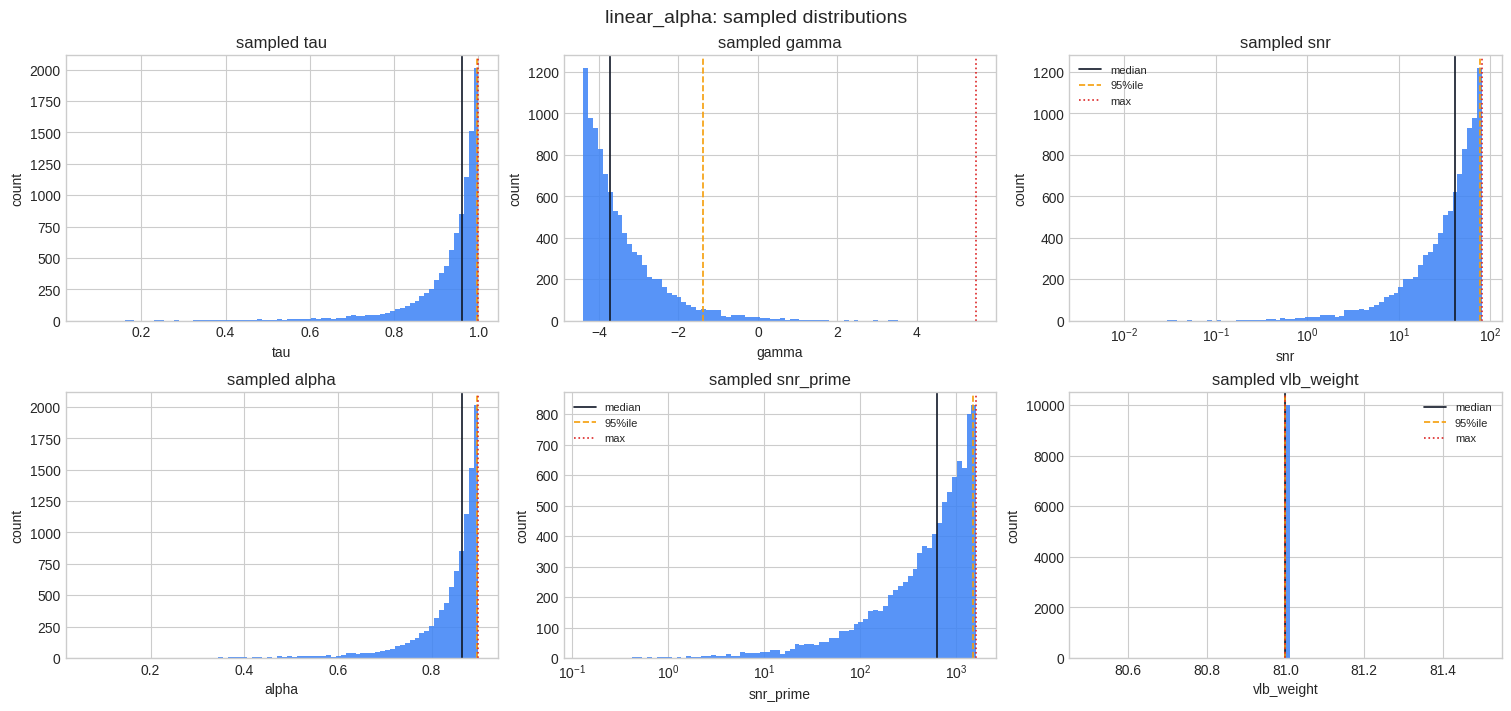

In [15]:
hist_names = [name for name in value_names if name != "sigma"]
fig, axes = plt.subplots(2, 3, figsize=(15, 7), constrained_layout=True)
axes = axes.ravel()

for ax, name in zip(axes, hist_names):
    arr = to_numpy(sampled[name])
    finite_arr = arr[np.isfinite(arr)]
    positive_arr = finite_arr[finite_arr > 0]
    use_log_bins = (
        name in {"snr", "snr_prime", "vlb_weight"}
        and positive_arr.size > 1
        and np.nanmax(positive_arr) / max(np.nanmin(positive_arr), 1e-300) > 100
    )
    if use_log_bins:
        bins = np.geomspace(np.nanmin(positive_arr), np.nanmax(positive_arr), 81)
        ax.hist(positive_arr, bins=bins, color="#3b82f6", alpha=0.85)
        ax.set_xscale("log")
        if positive_arr.size < finite_arr.size:
            ax.text(
                0.02, 0.95, f"excluded <=0: {finite_arr.size - positive_arr.size}",
                transform=ax.transAxes, va="top", fontsize=8)
    else:
        ax.hist(finite_arr, bins=80, color="#3b82f6", alpha=0.85)
    if finite_arr.size:
        ax.axvline(np.nanmedian(finite_arr), color="#111827", lw=1.2, label="median")
        ax.axvline(np.nanpercentile(finite_arr, 95), color="#f59e0b", lw=1.2, ls="--", label="95%ile")
        ax.axvline(np.nanmax(finite_arr), color="#dc2626", lw=1.2, ls=":", label="max")
    ax.set_title(f"sampled {name}")
    ax.set_xlabel(name)
    ax.set_ylabel("count")
    if name in {"snr", "snr_prime", "vlb_weight"}:
        ax.legend(fontsize=8)

for ax in axes[len(hist_names):]:
    ax.axis("off")

fig.suptitle(f"{SCHEDULE_TYPE}: sampled distributions", fontsize=14)
plt.show()

## Tau Curves

These plots show the deterministic schedule map from tau to gamma, SNR, alpha, and SNR-prime weight.

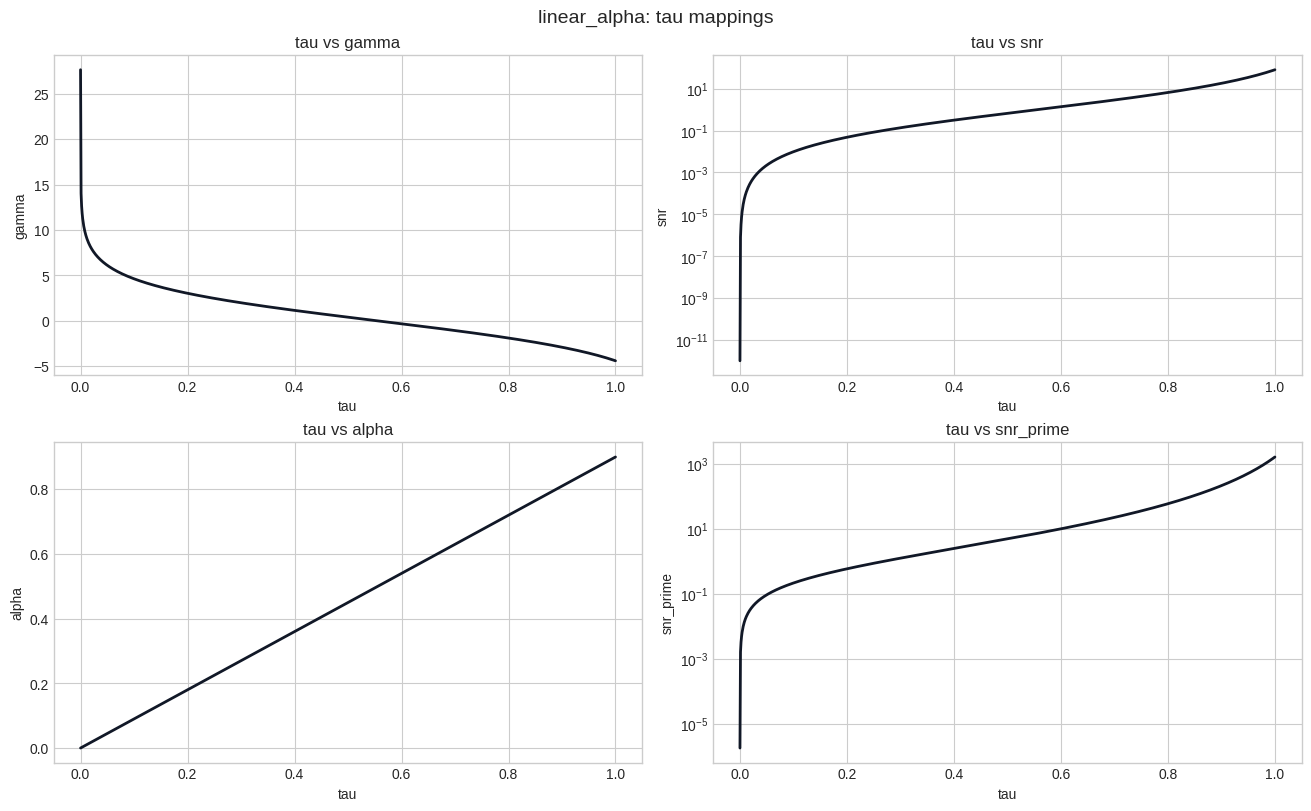

In [16]:
tau_grid = torch.linspace(T_MIN, T_MAX, GRID_POINTS)
curves = evaluate(schedule, tau_grid)

curve_specs = [
    ("gamma", "linear"),
    ("snr", "log"),
    ("alpha", "linear"),
    ("snr_prime", "log"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
axes = axes.ravel()
x = to_numpy(curves["tau"])

for ax, (name, scale) in zip(axes, curve_specs):
    y = to_numpy(curves[name])
    ax.plot(x, y, lw=2.0, color="#111827")
    ax.set_title(f"tau vs {name}")
    ax.set_xlabel("tau")
    ax.set_ylabel(name)
    if scale == "log":
        ax.set_yscale("log")

fig.suptitle(f"{SCHEDULE_TYPE}: tau mappings", fontsize=14)
plt.show()

## SNR prime factorization

The exact factorization is `snr_prime = |dSNR/dgamma| * (-dgamma/dtau)`, where `|dSNR/dgamma| = SNR`. If the peak lands exactly on `T_MIN` or `T_MAX`, rerun with a slightly clipped interval to distinguish endpoint behavior from interior schedule behavior.

Peak snr_prime at tau=1, gamma=-4.39445, SNR=81, -dgamma/dtau=20, snr_prime=1620


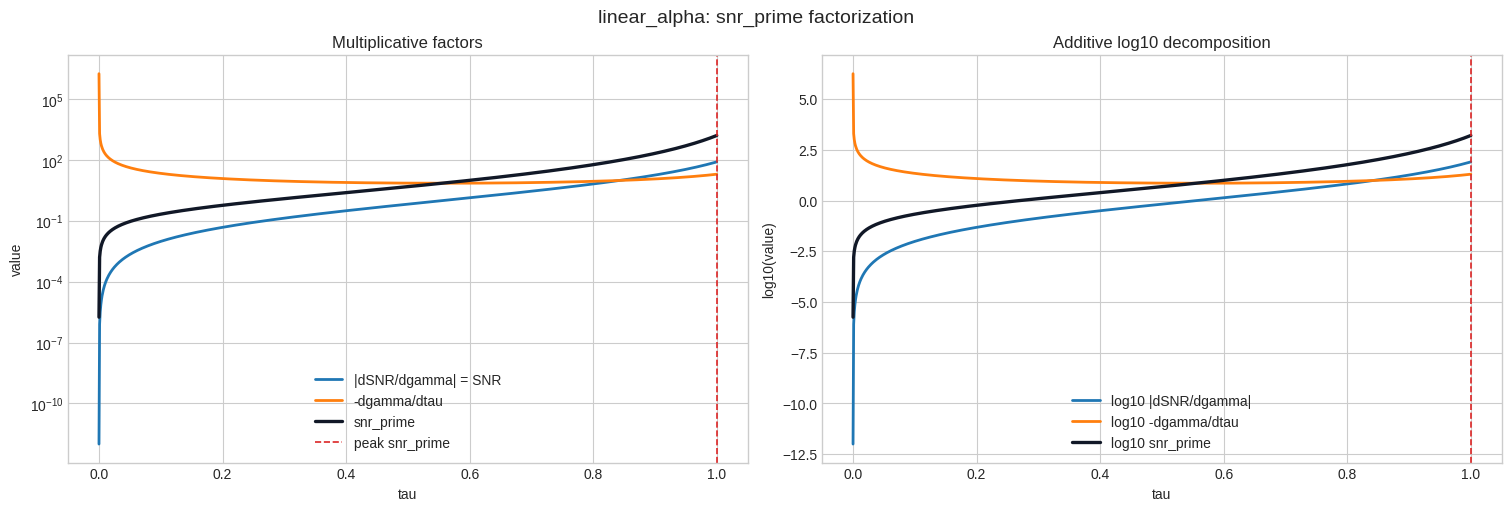

In [17]:
factor_curves = evaluate(schedule, tau_grid)

tau_arr = to_numpy(factor_curves["tau"])
abs_dsnr_dgamma = to_numpy(factor_curves["abs_dsnr_dgamma"])
neg_dgamma_dtau = to_numpy(factor_curves["neg_dgamma_dtau"])
snr_prime_curve = to_numpy(factor_curves["snr_prime"])

finite_prime = np.isfinite(snr_prime_curve)
peak_idx = int(np.nanargmax(np.where(finite_prime, snr_prime_curve, -np.inf)))
print(
    "Peak snr_prime at "
    f"tau={tau_arr[peak_idx]:.6g}, "
    f"gamma={to_numpy(factor_curves['gamma'])[peak_idx]:.6g}, "
    f"SNR={abs_dsnr_dgamma[peak_idx]:.6g}, "
    f"-dgamma/dtau={neg_dgamma_dtau[peak_idx]:.6g}, "
    f"snr_prime={snr_prime_curve[peak_idx]:.6g}"
)

eps_plot = np.finfo(np.float64).tiny
safe_abs_dsnr_dgamma = np.clip(abs_dsnr_dgamma, eps_plot, None)
safe_neg_dgamma_dtau = np.clip(neg_dgamma_dtau, eps_plot, None)
safe_snr_prime = np.clip(snr_prime_curve, eps_plot, None)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
factor_ax, log_ax = axes

factor_ax.plot(tau_arr, safe_abs_dsnr_dgamma, lw=2.0, label="|dSNR/dgamma| = SNR")
factor_ax.plot(tau_arr, safe_neg_dgamma_dtau, lw=2.0, label="-dgamma/dtau")
factor_ax.plot(tau_arr, safe_snr_prime, lw=2.4, color="#111827", label="snr_prime")
factor_ax.axvline(tau_arr[peak_idx], color="#dc2626", ls="--", lw=1.2, label="peak snr_prime")
factor_ax.set_title("Multiplicative factors")
factor_ax.set_xlabel("tau")
factor_ax.set_ylabel("value")
factor_ax.set_yscale("log")
factor_ax.legend()

log_ax.plot(tau_arr, np.log10(safe_abs_dsnr_dgamma), lw=2.0, label="log10 |dSNR/dgamma|")
log_ax.plot(tau_arr, np.log10(safe_neg_dgamma_dtau), lw=2.0, label="log10 -dgamma/dtau")
log_ax.plot(tau_arr, np.log10(safe_snr_prime), lw=2.4, color="#111827", label="log10 snr_prime")
log_ax.axvline(tau_arr[peak_idx], color="#dc2626", ls="--", lw=1.2)
log_ax.set_title("Additive log10 decomposition")
log_ax.set_xlabel("tau")
log_ax.set_ylabel("log10(value)")
log_ax.legend()

fig.suptitle(f"{SCHEDULE_TYPE}: snr_prime factorization", fontsize=14)
plt.show()

## Alpha vs. SNR-prime weight

This plot shows `snr_prime` directly against `alpha`, making it easier to see which signal levels are upweighted by the VLB/SNR-prime loss weight.

Peak snr_prime at alpha=0.9, tau=1, gamma=-4.39445, snr_prime=1620


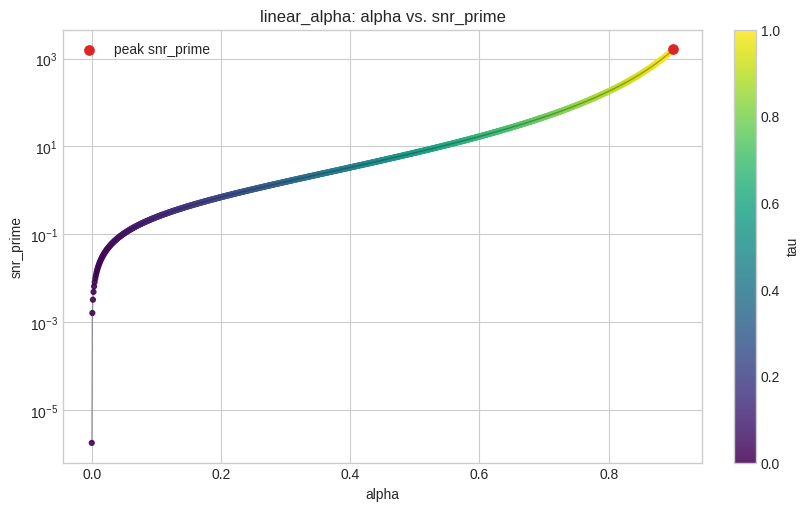

In [18]:
alpha_weight_curves = evaluate(schedule, tau_grid)

alpha_arr = to_numpy(alpha_weight_curves["alpha"])
tau_arr = to_numpy(alpha_weight_curves["tau"])
gamma_arr = to_numpy(alpha_weight_curves["gamma"])
snr_prime_alpha = to_numpy(alpha_weight_curves["snr_prime"])

finite = np.isfinite(alpha_arr) & np.isfinite(snr_prime_alpha)
alpha_finite = alpha_arr[finite]
tau_finite = tau_arr[finite]
snr_prime_finite = snr_prime_alpha[finite]

sort_idx = np.argsort(alpha_finite)
alpha_sorted = alpha_finite[sort_idx]
tau_sorted = tau_finite[sort_idx]
safe_snr_prime_sorted = np.clip(
    snr_prime_finite[sort_idx], np.finfo(np.float64).tiny, None)

peak_idx = int(np.nanargmax(np.where(
    np.isfinite(snr_prime_alpha), snr_prime_alpha, -np.inf)))
print(
    "Peak snr_prime at "
    f"alpha={alpha_arr[peak_idx]:.6g}, "
    f"tau={tau_arr[peak_idx]:.6g}, "
    f"gamma={gamma_arr[peak_idx]:.6g}, "
    f"snr_prime={snr_prime_alpha[peak_idx]:.6g}"
)

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
scatter = ax.scatter(
    alpha_sorted, safe_snr_prime_sorted, c=tau_sorted, s=12,
    cmap="viridis", alpha=0.85)
ax.plot(alpha_sorted, safe_snr_prime_sorted, color="#111827", lw=1.0, alpha=0.35)
ax.scatter(
    [alpha_arr[peak_idx]],
    [max(snr_prime_alpha[peak_idx], np.finfo(np.float64).tiny)],
    color="#dc2626", s=45, zorder=3, label="peak snr_prime")
ax.set_title(f"{SCHEDULE_TYPE}: alpha vs. snr_prime")
ax.set_xlabel("alpha")
ax.set_ylabel("snr_prime")
ax.set_yscale("log")
ax.legend()
fig.colorbar(scatter, ax=ax, label="tau")
plt.show()

## Alpha-bin loss mass

This bins the tau grid by `alpha` and compares ordinary tau-sampling mass with `snr_prime`-weighted objective mass. It shows which alpha ranges carry the most weighted loss, rather than only the pointwise weight.

Largest weighted alpha bin: alpha=[0.885, 0.9], weighted_share=27.3370%, tau_share=1.7017%, relative_weight=16.0645


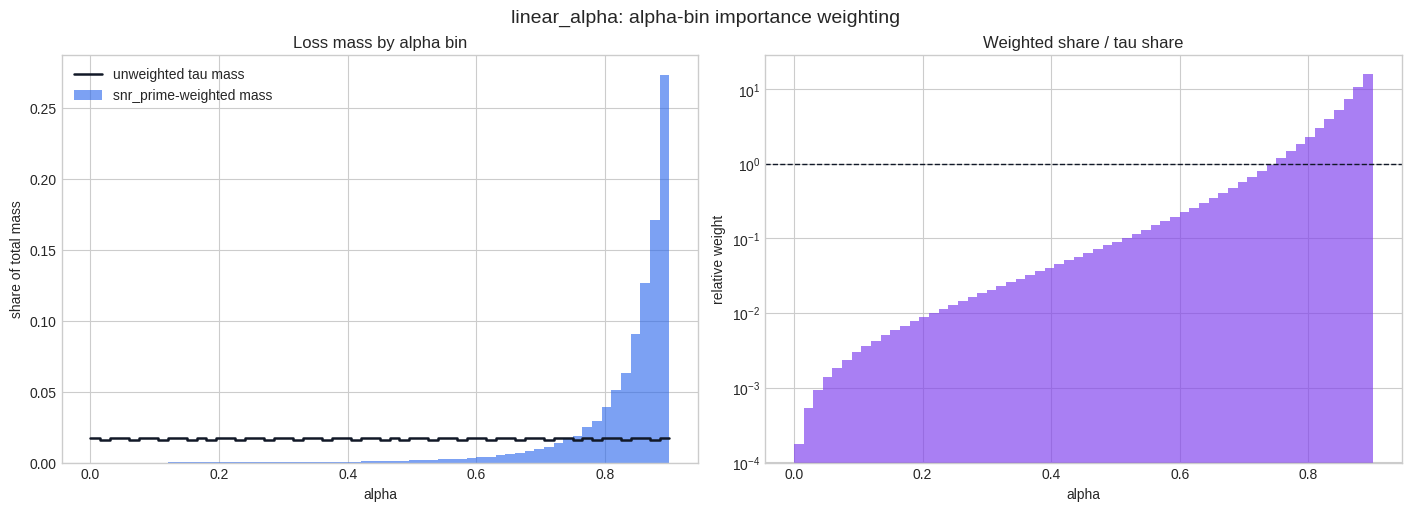

In [19]:
ALPHA_WEIGHT_BINS = 60

alpha_mass_curves = evaluate(schedule, tau_grid)
alpha_mass = to_numpy(alpha_mass_curves["alpha"])
tau_mass = to_numpy(alpha_mass_curves["tau"])
snr_prime_mass = to_numpy(alpha_mass_curves["snr_prime"])

finite = (
    np.isfinite(alpha_mass)
    & np.isfinite(tau_mass)
    & np.isfinite(snr_prime_mass)
)
alpha_mass = alpha_mass[finite]
tau_mass = tau_mass[finite]
snr_prime_mass = snr_prime_mass[finite]

tau_order = np.argsort(tau_mass)
alpha_mass = alpha_mass[tau_order]
tau_mass = tau_mass[tau_order]
snr_prime_mass = snr_prime_mass[tau_order]

if alpha_mass.size < 2:
    raise ValueError("Need at least two finite grid points to bin alpha mass")

alpha_mid = 0.5 * (alpha_mass[1:] + alpha_mass[:-1])
dtau = np.clip(np.diff(tau_mass), 0.0, None)
snr_prime_mid = 0.5 * (snr_prime_mass[1:] + snr_prime_mass[:-1])

alpha_lo = float(np.nanmin(alpha_mass))
alpha_hi = float(np.nanmax(alpha_mass))
if alpha_hi <= alpha_lo:
    raise ValueError("Alpha range is degenerate; cannot build alpha bins")

alpha_edges = np.linspace(alpha_lo, alpha_hi, ALPHA_WEIGHT_BINS + 1)
alpha_centers = 0.5 * (alpha_edges[1:] + alpha_edges[:-1])
alpha_widths = np.diff(alpha_edges)

tau_bin_mass, _ = np.histogram(alpha_mid, bins=alpha_edges, weights=dtau)
weighted_bin_mass, _ = np.histogram(
    alpha_mid,
    bins=alpha_edges,
    weights=np.clip(snr_prime_mid, 0.0, None) * dtau,
)

tau_total = tau_bin_mass.sum()
weighted_total = weighted_bin_mass.sum()
if tau_total <= 0 or weighted_total <= 0:
    raise ValueError("Alpha-bin mass is zero; check the tau grid and schedule")

tau_share = tau_bin_mass / tau_total
weighted_share = weighted_bin_mass / weighted_total
relative_weight = np.divide(
    weighted_share,
    tau_share,
    out=np.full_like(weighted_share, np.nan),
    where=tau_share > 0,
)

peak_bin = int(np.nanargmax(weighted_share))
print(
    "Largest weighted alpha bin: "
    f"alpha=[{alpha_edges[peak_bin]:.6g}, {alpha_edges[peak_bin + 1]:.6g}], "
    f"weighted_share={weighted_share[peak_bin]:.4%}, "
    f"tau_share={tau_share[peak_bin]:.4%}, "
    f"relative_weight={relative_weight[peak_bin]:.6g}"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
mass_ax, ratio_ax = axes

mass_ax.bar(
    alpha_centers, weighted_share, width=alpha_widths,
    color="#2563eb", alpha=0.6, label="snr_prime-weighted mass")
mass_ax.step(
    alpha_edges, np.r_[tau_share, tau_share[-1]], where="post",
    color="#111827", lw=1.8, label="unweighted tau mass")
mass_ax.set_title("Loss mass by alpha bin")
mass_ax.set_xlabel("alpha")
mass_ax.set_ylabel("share of total mass")
mass_ax.legend()

safe_relative_weight = np.clip(relative_weight, np.finfo(np.float64).tiny, None)
ratio_ax.bar(
    alpha_centers, safe_relative_weight, width=alpha_widths,
    color="#7c3aed", alpha=0.65)
ratio_ax.axhline(1.0, color="#111827", lw=1.0, ls="--")
ratio_ax.set_title("Weighted share / tau share")
ratio_ax.set_xlabel("alpha")
ratio_ax.set_ylabel("relative weight")
ratio_ax.set_yscale("log")

fig.suptitle(f"{SCHEDULE_TYPE}: alpha-bin importance weighting", fontsize=14)
plt.show()

## Compare All Schedules

This builds every schedule with the same config and uses `IMPORTANCE_SAMPLING` to choose the tau values shown in the overlay plots and sampled summary table. The prior KL/token panel remains a deterministic endpoint calculation at `T_MIN`. `argmax_uncertainty` is the most expensive to build; reduce `n_points` above if this cell is slow.

In [ ]:
schedule_names = [
    "argmax_uncertainty",
    "linear_alpha",
    "cosine_alpha",
    # "ode_alpha",
    # "piecewise_alpha",
]
schedules = {name: make_schedule(name) for name in schedule_names}
comparison_mode = sample_mode_name()
comparison_samples = {
    name: sample_schedule(sched, importance_sampling=IMPORTANCE_SAMPLING)
    for name, sched in schedules.items()
}
prior_records = [
    prior_kl_record(name, sched, tau_value=T_MIN)
    for name, sched in schedules.items()
]

fig, axes = plt.subplots(2, 3, figsize=(18, 8), constrained_layout=True)
axes = axes.ravel()
curve_axes = axes[:4]
prior_ax = axes[4]
table_ax = axes[5]

for name, vals in comparison_samples.items():
    tau_vals = to_numpy(vals["tau"])
    finite_tau = np.isfinite(tau_vals)
    if not finite_tau.any():
        continue
    order = np.argsort(tau_vals[finite_tau])
    finite_indices = np.flatnonzero(finite_tau)[order]
    if finite_indices.size > GRID_POINTS:
        finite_indices = finite_indices[
            np.linspace(0, finite_indices.size - 1, GRID_POINTS).round().astype(int)
        ]
    for ax, (metric, scale) in zip(curve_axes, curve_specs):
        y_vals = to_numpy(vals[metric])[finite_indices]
        x_vals = tau_vals[finite_indices]
        if scale == "log":
            y_vals = np.clip(y_vals, np.finfo(np.float64).tiny, None)
        ax.plot(x_vals, y_vals, label=name, lw=1.4, alpha=0.85)
        ax.scatter(x_vals, y_vals, s=4, alpha=0.12)
        ax.set_title(f"sampled tau vs {metric}")
        ax.set_xlabel("sampled tau")
        ax.set_ylabel(metric)
        if scale == "log":
            ax.set_yscale("log")

for ax in curve_axes:
    ax.legend(fontsize=8)

prior_names = [row["schedule"] for row in prior_records]
prior_values = np.array([row["prior_kl_per_token"] for row in prior_records])
prior_ax.barh(prior_names, prior_values, color=plt.cm.tab10(np.linspace(0, 1, len(prior_values))))
prior_ax.set_title(f"prior KL/token at tau={T_MIN:g} (sampling independent)")
prior_ax.set_xlabel("prior KL/token")
positive_prior = prior_values[prior_values > 0]
if positive_prior.size and prior_values.max() / positive_prior.min() > 100:
    prior_ax.set_xscale("symlog", linthresh=positive_prior.min())
prior_ax.invert_yaxis()

prior_by_name = {row["schedule"]: row for row in prior_records}

def finite_percentile(values, q):
    arr = to_numpy(values)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return np.nan
    return np.percentile(arr, q)

table_rows = []
for name, vals in comparison_samples.items():
    row = prior_by_name[name]
    table_rows.append([
        name,
        f"{row['prior_kl_per_token']:.4g}",
        f"{finite_percentile(vals['tau'], 50):.4g}",
        f"{finite_percentile(vals['gamma'], 50):.4g}",
        f"{finite_percentile(vals['snr'], 95):.4g}",
        f"{finite_percentile(vals['vlb_weight'], 50):.4g}",
    ])

table_ax.axis("off")
table_ax.set_title(f"sampled summary ({comparison_mode}, n={N_SAMPLES:,})")
table = table_ax.table(
    cellText=table_rows,
    colLabels=["schedule", "prior KL", "median tau", "median gamma", "95% SNR", "median weight"],
    loc="center",
    cellLoc="right",
    colLoc="right",
)
table.auto_set_font_size(False)
table.set_fontsize(7)
table.scale(1.0, 1.25)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
    if col == 0:
        cell.set_text_props(ha="left")

fig.suptitle(f"Schedule comparison ({comparison_mode})", fontsize=14)
plt.show()

ValueError: alpha_min must be greater than 0

## Argmax Correctness at effective gamma_min

This diagnostic verifies whether the Gaussian latent at the active sampler's effective `gamma_min` preserves the original token under an argmax decoder. It derives the point from the maximum finite SNR reached by the current sampling mode (`IMPORTANCE_SAMPLING=True` samples uniformly in SNR; `False` samples uniformly in tau), then compares the exact Gaussian order-statistic probability against a fast Monte Carlo estimate that samples only the target-coordinate noise and the maximum non-target noise coordinate.

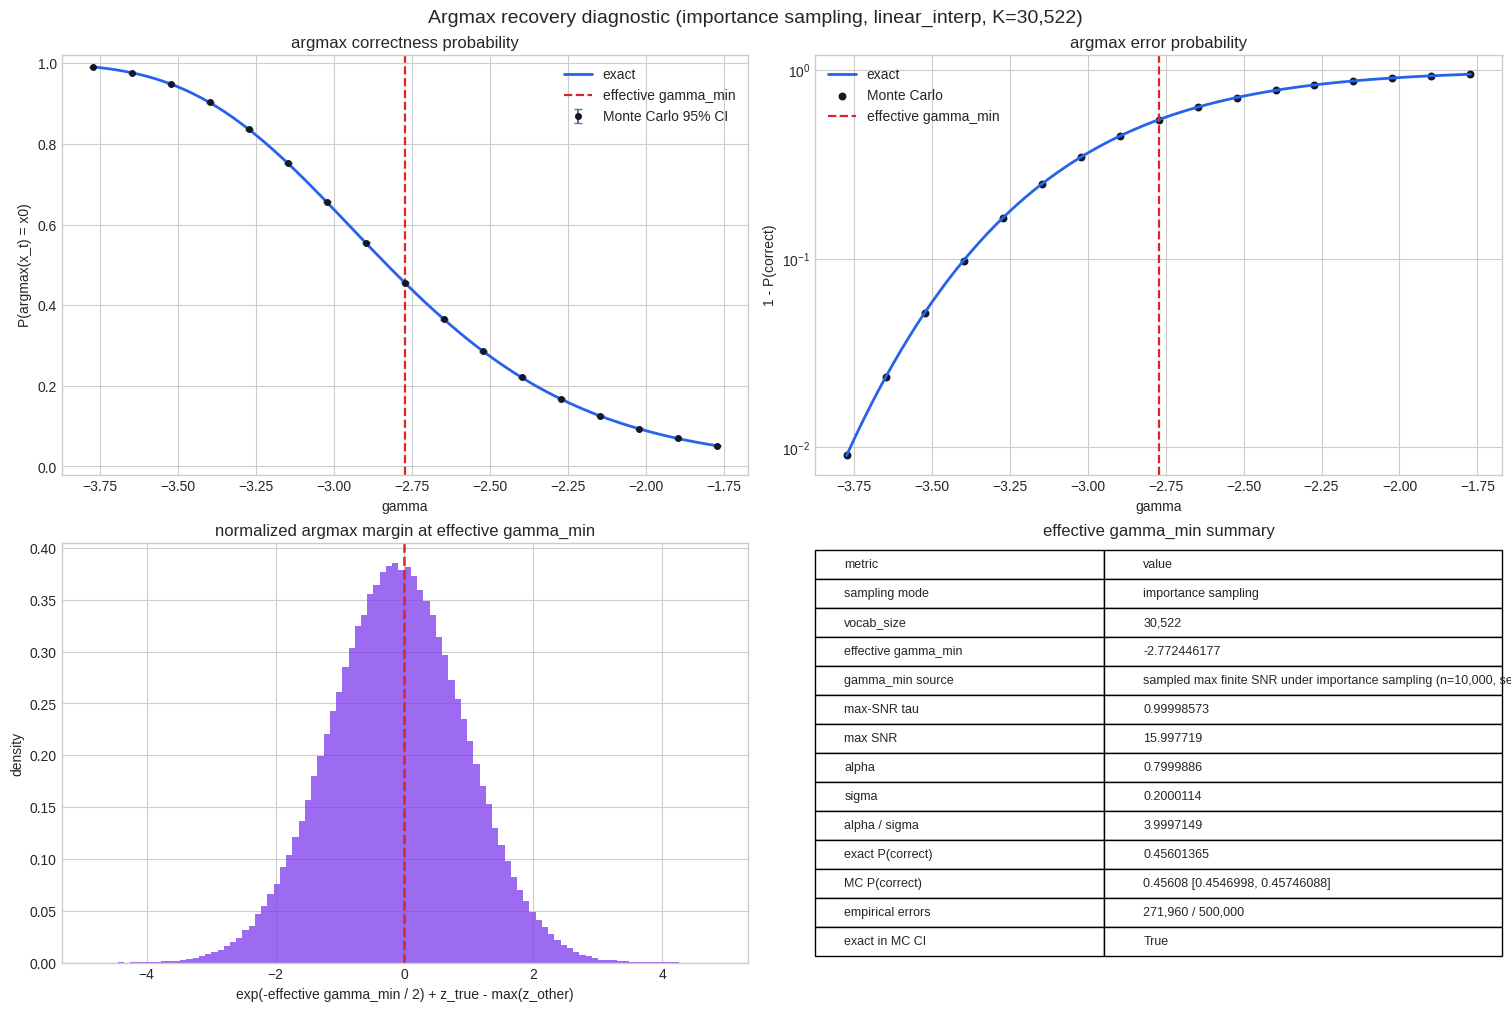

In [ ]:
from numpy.polynomial.hermite import hermgauss
from scipy.special import log_ndtr, ndtr, ndtri

ARGMAX_MC_TRIALS = 500_000
ARGMAX_GAMMA_HALF_WIDTH = 1.0
ARGMAX_GAMMA_POINTS = 81
TARGET_CORRECT_PROB = None


def exact_argmax_correctness(gamma_values, vocab_size, n_gh=96):
    gamma_values = np.asarray(gamma_values, dtype=np.float64)
    vocab_size = int(vocab_size)
    if vocab_size < 2:
        raise ValueError("vocab_size must be at least 2")

    margins = np.exp(-0.5 * gamma_values)
    nodes, weights = hermgauss(int(n_gh))
    weights = weights / np.sqrt(np.pi)
    z_nodes = np.sqrt(2.0) * nodes
    log_terms = (vocab_size - 1) * log_ndtr(z_nodes[None, :] + margins[:, None])
    return np.sum(weights[None, :] * np.exp(log_terms), axis=1)


def wilson_interval(successes, trials, confidence_z=1.959963984540054):
    successes = np.asarray(successes, dtype=np.float64)
    trials = float(trials)
    phat = successes / trials
    denom = 1.0 + confidence_z ** 2 / trials
    center = (phat + confidence_z ** 2 / (2.0 * trials)) / denom
    half_width = confidence_z * np.sqrt(
        (phat * (1.0 - phat) + confidence_z ** 2 / (4.0 * trials)) / trials
    ) / denom
    low = np.clip(center - half_width, 0.0, 1.0)
    high = np.clip(center + half_width, 0.0, 1.0)
    return low, high


def snr_from_log_snr(log_snr_value):
    return (
        float(np.exp(log_snr_value))
        if log_snr_value < np.log(np.finfo(np.float64).max)
        else float("inf")
    )


def gamma_min_record(gamma, tau, source):
    gamma = np.asarray(gamma, dtype=np.float64)
    tau = np.asarray(tau, dtype=np.float64)
    log_snr = -gamma
    finite = np.isfinite(gamma) & np.isfinite(log_snr) & np.isfinite(tau)
    if not finite.any():
        raise ValueError("No finite gamma/SNR values found while inferring effective gamma_min")

    finite_indices = np.flatnonzero(finite)
    idx = int(finite_indices[int(np.nanargmax(log_snr[finite]))])
    log_snr_value = float(log_snr[idx])
    return {
        "gamma": float(gamma[idx]),
        "tau": float(tau[idx]),
        "snr": snr_from_log_snr(log_snr_value),
        "source": source,
    }


def infer_effective_gamma_min(
    schedule,
    importance_sampling=None,
    n=None,
    t_min=None,
    t_max=None,
    seed=None,
):
    if importance_sampling is None:
        importance_sampling = IMPORTANCE_SAMPLING
    if n is None:
        n = N_SAMPLES
    if t_min is None:
        t_min = T_MIN
    if t_max is None:
        t_max = T_MAX
    if seed is None:
        seed = SEED

    sampled_values = sample_schedule(
        schedule,
        importance_sampling=importance_sampling,
        n=n,
        t_min=t_min,
        t_max=t_max,
        seed=seed,
    )
    return gamma_min_record(
        to_numpy(sampled_values["gamma"]),
        to_numpy(sampled_values["tau"]),
        (
            f"sampled max finite SNR under {sample_mode_name(importance_sampling)} "
            f"(n={int(n):,}, seed={int(seed)})"
        ),
    )


vocab_size = int(SCHEDULE_PARAMS["vocab_size"])
argmax_schedule = make_schedule(SCHEDULE_TYPE)
gamma_min_info = infer_effective_gamma_min(argmax_schedule)
gamma_min_value = gamma_min_info["gamma"]
gamma_grid = np.linspace(
    gamma_min_value - ARGMAX_GAMMA_HALF_WIDTH,
    gamma_min_value + ARGMAX_GAMMA_HALF_WIDTH,
    ARGMAX_GAMMA_POINTS,
)
exact_correct = exact_argmax_correctness(gamma_grid, vocab_size)
exact_at_gamma_min = exact_argmax_correctness([gamma_min_value], vocab_size)[0]

assert np.all(np.diff(exact_correct) <= 1e-10), "P(correct) should decrease as gamma increases"
k2_gamma = np.array([gamma_min_value], dtype=np.float64)
k2_margin = np.exp(-0.5 * k2_gamma[0])
k2_exact = exact_argmax_correctness(k2_gamma, vocab_size=2)[0]
k2_closed_form = ndtr(k2_margin / np.sqrt(2.0))
assert np.allclose(k2_exact, k2_closed_form, atol=5e-5), "K=2 sanity check failed"

rng = np.random.default_rng(SEED)
u = np.clip(rng.random(ARGMAX_MC_TRIALS), np.finfo(np.float64).tiny, 1.0 - np.finfo(np.float64).eps)
z_true = rng.standard_normal(ARGMAX_MC_TRIALS)
# Stable equivalent of ndtri(u ** (1.0 / (vocab_size - 1))).
max_other = -ndtri(-np.expm1(np.log(u) / (vocab_size - 1)))

mc_indices = np.unique(np.linspace(0, ARGMAX_GAMMA_POINTS - 1, min(17, ARGMAX_GAMMA_POINTS)).round().astype(int))
mc_gamma = gamma_grid[mc_indices]
mc_margins = np.exp(-0.5 * mc_gamma)
mc_successes = np.array([np.count_nonzero(margin + z_true > max_other) for margin in mc_margins])
mc_correct = mc_successes / ARGMAX_MC_TRIALS
mc_ci_low, mc_ci_high = wilson_interval(mc_successes, ARGMAX_MC_TRIALS)
mc_yerr = np.maximum(0.0, np.vstack([mc_correct - mc_ci_low, mc_ci_high - mc_correct]))

gamma_min_margin = np.exp(-0.5 * gamma_min_value)
gamma_min_normalized_margin = gamma_min_margin + z_true - max_other
gamma_min_successes = np.count_nonzero(gamma_min_normalized_margin > 0.0)
gamma_min_mc_correct = gamma_min_successes / ARGMAX_MC_TRIALS
gamma_min_ci_low, gamma_min_ci_high = wilson_interval(gamma_min_successes, ARGMAX_MC_TRIALS)
ci_contains_exact = gamma_min_ci_low <= exact_at_gamma_min <= gamma_min_ci_high

gamma_min_tensor = torch.tensor(gamma_min_value, dtype=torch.get_default_dtype())
alpha_min, sigma_min = alpha_sigma_from_gamma(gamma_min_tensor)
alpha_min = float(alpha_min.detach().cpu())
sigma_min = float(sigma_min.detach().cpu())

fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)
prob_ax, err_ax, margin_ax, table_ax = axes.ravel()

prob_ax.plot(gamma_grid, exact_correct, color="#2563eb", lw=2.0, label="exact")
prob_ax.errorbar(
    mc_gamma,
    mc_correct,
    yerr=mc_yerr,
    fmt="o",
    ms=4,
    color="#111827",
    ecolor="#6b7280",
    capsize=3,
    label="Monte Carlo 95% CI",
)
prob_ax.axvline(gamma_min_value, color="#dc2626", ls="--", lw=1.6, label="effective gamma_min")
if TARGET_CORRECT_PROB is not None:
    prob_ax.axhline(float(TARGET_CORRECT_PROB), color="#059669", ls=":", lw=1.8, label="target")
prob_ax.set_title("argmax correctness probability")
prob_ax.set_xlabel("gamma")
prob_ax.set_ylabel("P(argmax(x_t) = x0)")
prob_ax.set_ylim(-0.02, 1.02)
prob_ax.legend()

error_floor = max(1e-12, 0.5 / ARGMAX_MC_TRIALS)
err_ax.plot(gamma_grid, np.clip(1.0 - exact_correct, error_floor, None), color="#2563eb", lw=2.0, label="exact")
err_ax.scatter(mc_gamma, np.clip(1.0 - mc_correct, error_floor, None), color="#111827", s=22, label="Monte Carlo")
err_ax.axvline(gamma_min_value, color="#dc2626", ls="--", lw=1.6, label="effective gamma_min")
err_ax.set_title("argmax error probability")
err_ax.set_xlabel("gamma")
err_ax.set_ylabel("1 - P(correct)")
err_ax.set_yscale("log")
err_ax.legend()

margin_ax.hist(gamma_min_normalized_margin, bins=100, density=True, color="#7c3aed", alpha=0.75)
margin_ax.axvline(0.0, color="#dc2626", ls="--", lw=1.8)
margin_ax.set_title("normalized argmax margin at effective gamma_min")
margin_ax.set_xlabel("exp(-effective gamma_min / 2) + z_true - max(z_other)")
margin_ax.set_ylabel("density")

summary_rows = [
    ("sampling mode", sample_mode_name()),
    ("vocab_size", f"{vocab_size:,}"),
    ("effective gamma_min", f"{gamma_min_value:.10g}"),
    ("gamma_min source", gamma_min_info["source"]),
    ("max-SNR tau", f"{gamma_min_info['tau']:.8g}"),
    ("max SNR", f"{gamma_min_info['snr']:.8g}"),
    ("alpha", f"{alpha_min:.8g}"),
    ("sigma", f"{sigma_min:.8g}"),
    ("alpha / sigma", f"{gamma_min_margin:.8g}"),
    ("exact P(correct)", f"{exact_at_gamma_min:.8g}"),
    ("MC P(correct)", f"{gamma_min_mc_correct:.8g} [{gamma_min_ci_low:.8g}, {gamma_min_ci_high:.8g}]"),
    ("empirical errors", f"{ARGMAX_MC_TRIALS - gamma_min_successes:,} / {ARGMAX_MC_TRIALS:,}"),
    ("exact in MC CI", str(bool(ci_contains_exact))),
]
table_ax.axis("off")
summary_table = table_ax.table(
    cellText=summary_rows,
    colLabels=["metric", "value"],
    cellLoc="left",
    colLoc="left",
    loc="center",
    colWidths=[0.42, 0.58],
)
summary_table.auto_set_font_size(False)
summary_table.set_fontsize(9)
summary_table.scale(1.0, 1.45)
table_ax.set_title("effective gamma_min summary")

fig.suptitle(
    f"Argmax recovery diagnostic ({sample_mode_name()}, {LATENT_TYPE}, K={vocab_size:,})",
    fontsize=14,
)
plt.show()

## Importance Sampling View

Compare the current schedule under uniform `tau` sampling and importance sampling. This keeps the schedule fixed, shows how the induced `tau`, `gamma`, and `snr` distributions shift, and reports the corresponding summary statistics.

LinearAlphaSchedule comparison (latent_type=linear_interp, t=[0.0, 1.0])

uniform tau sampling
value                 mean           std           min        median        75%ile        90%ile        95%ile           max
tau                0.50331       0.28878    5.0617e-05      0.505202      0.749941      0.903515      0.950563      0.999857
gamma              1.20431       2.69226      -2.77117      0.772202       2.73294       4.77226       6.34608       13.7341
snr                2.02041        3.3239   1.08478e-06      0.461994       2.25381       6.80644       10.0829       15.9772
alpha             0.403145      0.230735    0.00104044      0.404656      0.600203      0.722908      0.760499      0.799886
sigma             0.596855      0.230735      0.200114      0.595344      0.796809      0.915763      0.959807       0.99896
snr_prime          16.3801       30.0866    0.00166783        3.0645       15.0092       54.2988       88.4619       159.505
vlb_weight         16.3801    

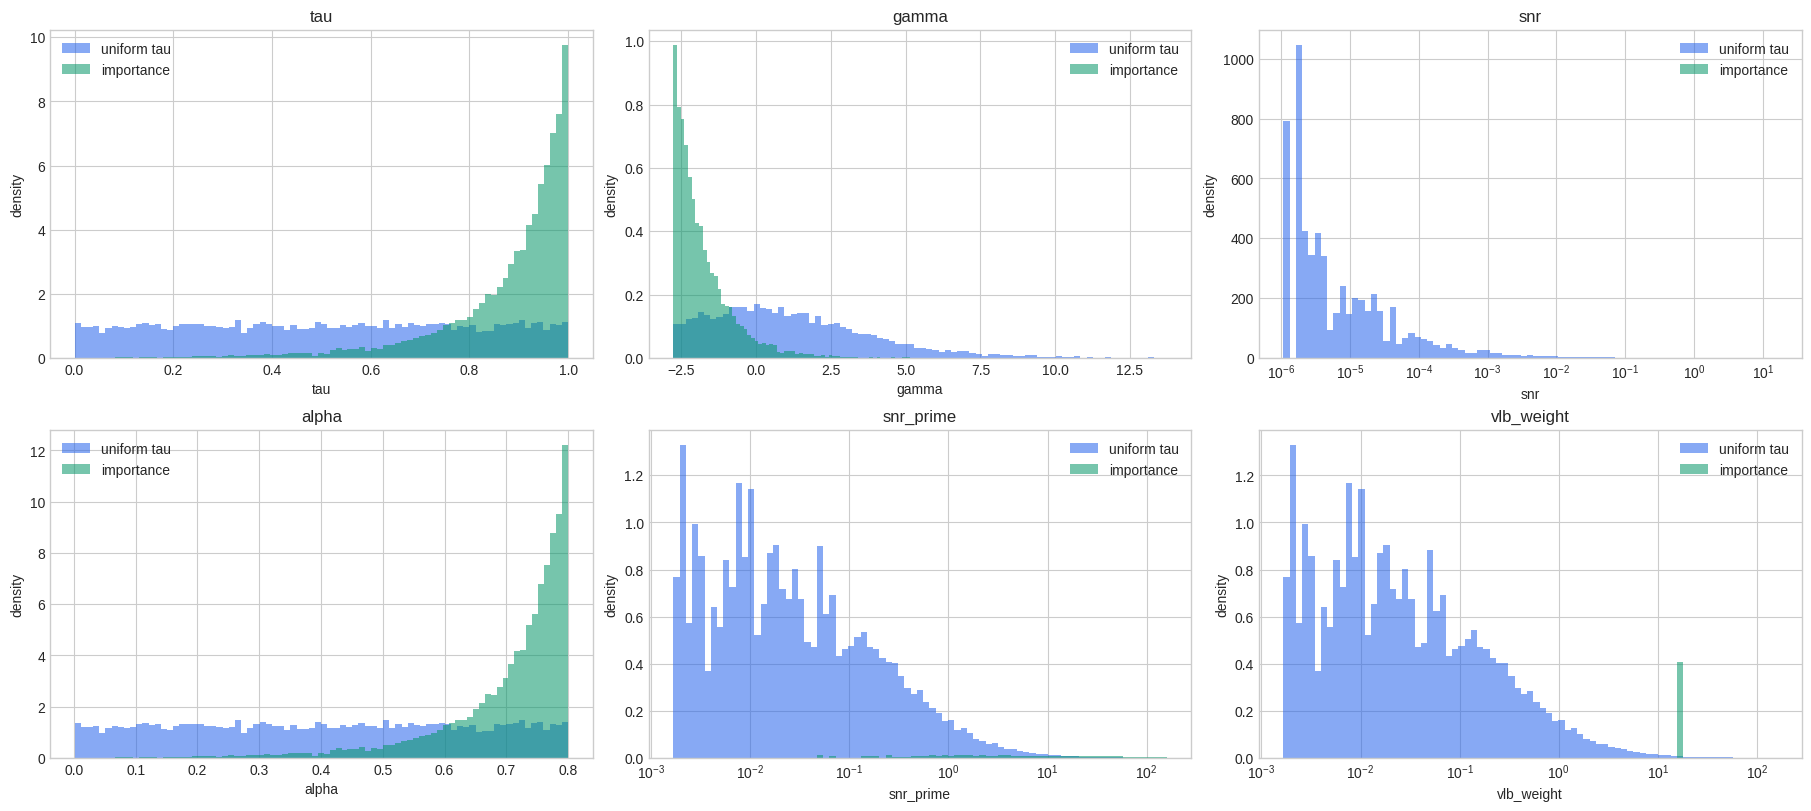

In [ ]:
comparison_schedule = make_schedule(SCHEDULE_TYPE)
compare_uniform = evaluate(comparison_schedule, uniform_tau())
compare_importance = evaluate_importance(comparison_schedule)

print(f"{type(comparison_schedule).__name__} comparison (latent_type={LATENT_TYPE}, t=[{T_MIN}, {T_MAX}])")
print()
print("uniform tau sampling")
summarize(compare_uniform, ["tau", "gamma", "snr", "alpha", "sigma", "snr_prime", "vlb_weight"])
print()
print("importance sampling")
summarize(compare_importance, ["tau", "gamma", "snr", "alpha", "sigma", "snr_prime", "vlb_weight"])

fig, axes = plt.subplots(2, 3, figsize=(18, 8), constrained_layout=True)
axes = axes.ravel()
metrics = ["tau", "gamma", "snr", "alpha", "snr_prime", "vlb_weight"]
colors = {
    "uniform": "#2563eb",
    "importance": "#059669",
}

for ax, metric in zip(axes, metrics):
    uniform_arr = to_numpy(compare_uniform[metric])
    importance_arr = to_numpy(compare_importance[metric])
    use_log_x = metric in {"snr", "snr_prime", "vlb_weight"}
    if use_log_x:
        combined = np.concatenate([uniform_arr, importance_arr])
        positive = combined[np.isfinite(combined) & (combined > 0)]
    if use_log_x and positive.size > 0 and positive.max() > positive.min():
        bins = np.geomspace(max(positive.min(), 1e-12), positive.max(), 80)
    else:
        bins = 80
        use_log_x = False
    ax.hist(
        uniform_arr,
        bins=bins,
        density=True,
        alpha=0.55,
        color=colors["uniform"],
        label="uniform tau",
    )
    ax.hist(
        importance_arr,
        bins=bins,
        density=True,
        alpha=0.55,
        color=colors["importance"],
        label="importance",
    )
    ax.set_title(metric)
    ax.set_xlabel(metric)
    ax.set_ylabel("density")
    if use_log_x:
        ax.set_xscale("log")
    ax.legend()

for ax in axes[len(metrics):]:
    ax.set_visible(False)

plt.show()